In [1]:
#importa librerias
import pandas as pd

In [2]:
import numpy as np

In [47]:
import matplotlib.pyplot as plt

In [48]:
import seaborn as sns

In [4]:
# carga el archivo de dataset
ventas = pd.read_csv("ventas-por-factura.csv")

In [5]:
# Explorar el dataset
print(ventas.head())


  N° de factura     Fecha de factura  ID Cliente            País  Cantidad  \
0        548370   3/30/2021 16:14:00     15528.0  United Kingdom       123   
1        575767  11/11/2021 11:11:00     17348.0  United Kingdom       163   
2       C570727  10/12/2021 11:32:00     12471.0         Germany        -1   
3        549106    4/6/2021 12:08:00     17045.0  United Kingdom         1   
4        573112  10/27/2021 15:33:00     16416.0  United Kingdom       357   

    Monto  
0  229,33  
1  209,73  
2   -1,45  
3   39,95  
4  344,83  


In [11]:
#Informacion de olumnas
print(ventas.columns)

Index(['N° de factura', 'Fecha de factura', 'ID Cliente', 'País', 'Cantidad',
       'Monto'],
      dtype='object')


In [41]:
#identificacion de valores nulos 
print(ventas.isnull().sum())

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64


In [42]:
#Outliers (Negativos )
# Cantidades negativas
negativos = ventas[ventas["Cantidad"] < 0]

print("Cantidad de registros negativos:")
print(len(negativos))

Cantidad de registros negativos:
5179


In [43]:
#outliers fuera de rango
Q1 = ventas["Monto"].quantile(0.25)
Q3 = ventas["Monto"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

outliers = ventas[
    (ventas["Monto"] < limite_inferior) |
    (ventas["Monto"] > limite_superior)
]

print("Cantidad de outliers:")
print(len(outliers))

Cantidad de outliers:
1975


In [15]:
#cantidades negativas 
print("Cantidades negativas:",
      (ventas["Cantidad"] < 0).sum())

Cantidades negativas: 5179


In [44]:
#facturas canceladas 
canceladas = ventas[
    ventas["N° de factura"]
    .astype(str)
    .str.startswith("C")
]

print("Facturas canceladas:")
print(len(canceladas))

Facturas canceladas:
3841


In [45]:
#datos duplicados 
print("\nDuplicados:")
print(ventas_limpio.duplicated().sum())


Duplicados:
0


In [46]:
#problemas de formato 
print(ventas.dtypes)

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                 float64
País                        object
Cantidad                     int64
Monto                      float64
dtype: object


In [29]:
#limpiar ventas
ventas_limpio = ventas.copy()

In [30]:
#limpiar datos duplicados 
ventas_limpio = ventas_limpio.drop_duplicates()

In [31]:
#limpiar datos
ventas_limpio = ventas_limpio.dropna()

In [32]:
#transformar datos 
ventas_limpio = ventas_limpio[
    ~ventas_limpio["N° de factura"]
    .astype(str)
    .str.startswith("C")
]

In [33]:
#transformar datos 
ventas_limpio = ventas_limpio[
    ventas_limpio["Cantidad"] > 0
]

In [34]:
#transformar datos 
ventas_limpio["Año"] = (
    ventas_limpio["Fecha de factura"]
    .dt.year
)

ventas_limpio["Mes"] = (
    ventas_limpio["Fecha de factura"]
    .dt.month
)

In [35]:
#comprobar la limpieza 
print("Registros originales:", len(ventas))

Registros originales: 25953


In [36]:
#registros limpios 
print("Registros limpios:", len(ventas_limpio))

Registros limpios: 18566


In [37]:
#valores nulos 
print("\nValores nulos:")
print(ventas_limpio.isnull().sum())


Valores nulos:
N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
Año                 0
Mes                 0
dtype: int64


In [38]:
#datos duplicados 
print("\nDuplicados:")
print(ventas_limpio.duplicated().sum())


Duplicados:
0


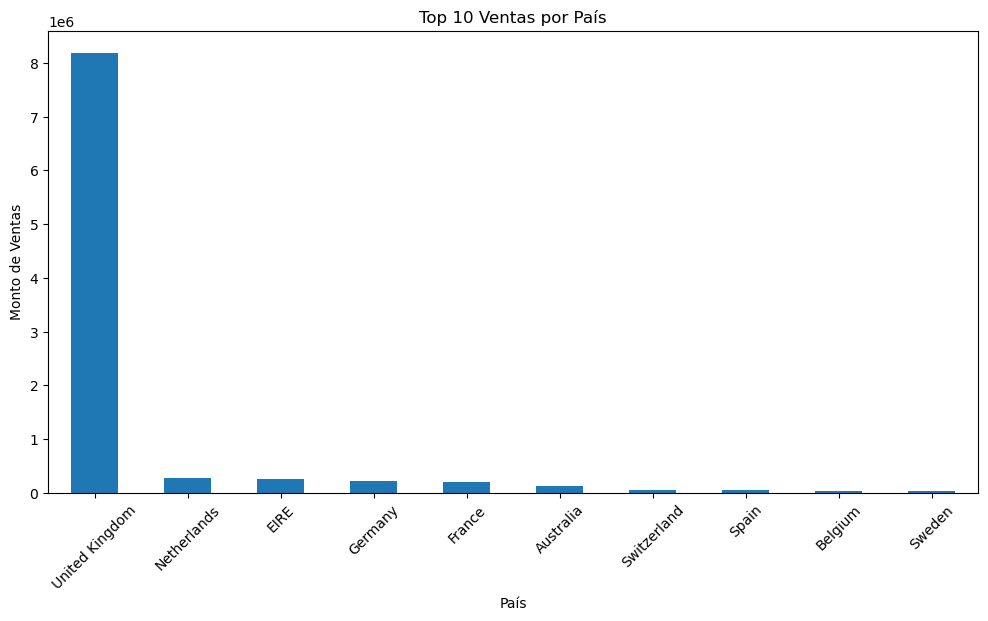

In [49]:
#graficas venta por pais 
ventas_pais = ventas.groupby("País")["Monto"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
ventas_pais.head(10).plot(kind="bar")

plt.title("Top 10 Ventas por País")
plt.xlabel("País")
plt.ylabel("Monto de Ventas")
plt.xticks(rotation=45)

plt.show()

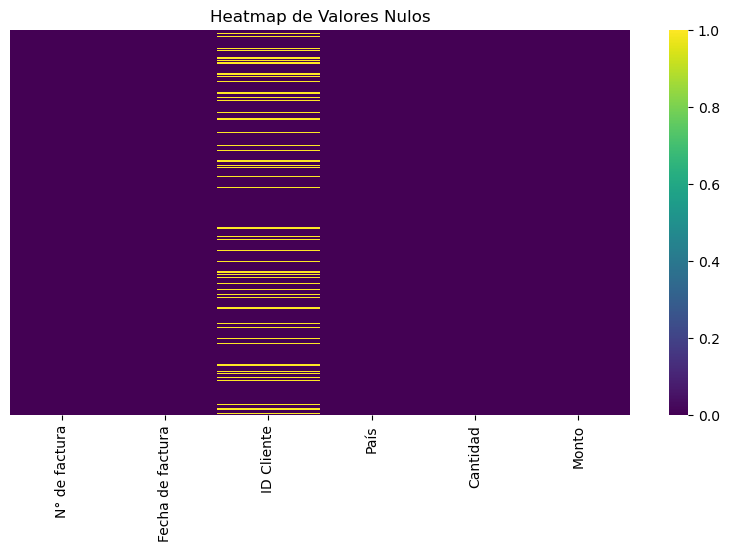

In [50]:
#Gráfica 2: Heatmap de Valores Nulos
plt.figure(figsize=(10,5))

sns.heatmap(
    ventas.isnull(),
    cbar=True,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Heatmap de Valores Nulos")

plt.show()

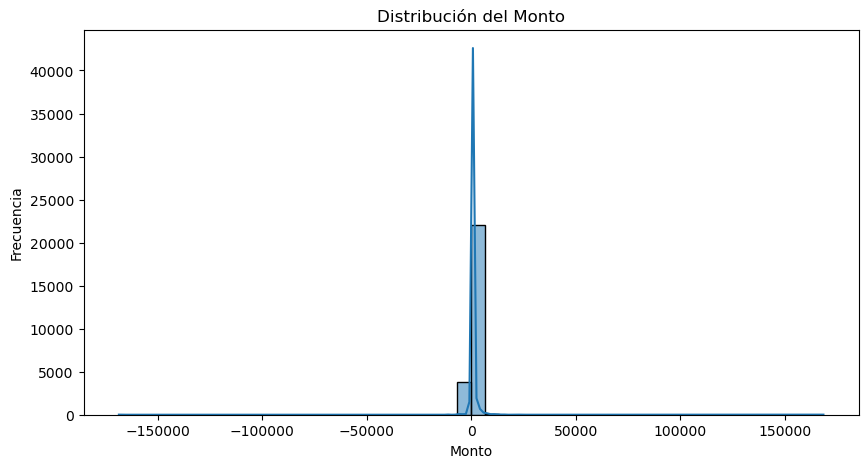

In [51]:
#Gráfica 3: Distribución del Monto
plt.figure(figsize=(10,5))

sns.histplot(
    ventas["Monto"],
    bins=50,
    kde=True
)

plt.title("Distribución del Monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.show()

#Justificación de las decisiones tomadas: Se eliminaron los valores nulos para evitar información incompleta, los registros duplicados para prevenir conteos incorrectos, las facturas canceladas porque no representan ventas reales y los registros con cantidades negativas por considerarse devoluciones o datos no válidos para el análisis de ventas. Además, se corrigieron los formatos de fecha y monto para garantizar que los cálculos, gráficas y análisis se realizaran correctamente y con datos consistentes.

#Cómo afecta el principio GIGO al análisis de datos y Machine Learning? El principio GIGO (Garbage In, Garbage Out) establece que la calidad de los resultados depende de la calidad de los datos utilizados. Si los datos contienen errores, valores nulos, duplicados o información incorrecta, los análisis realizados y los modelos de Machine Learning producirán resultados poco confiables o erróneos. Por ello, es fundamental realizar procesos de limpieza y transformación de datos antes de analizarlos o utilizarlos para entrenar modelos.